In [17]:
print(" Base de Dados — Justificativa")

print(" Dataset: Satellite telemetry data anomaly prediction")
print(" Fonte: Kaggle")
print(" Contexto: Dados de telemetria espacial contendo métricas de segmentos de sinal,incluindo média dos segmentos (mean) e número de picos detectados (n_peaks).")
print(" Justificativa: O dataset foi selecionado por conter variáveis quantitativas contínuas e discretas reais, com volume adequado para análise estatística (amostra de 100 registros).")
print(" Os dados são relevantes ao contexto da nova economia espacial pois permitem analisar padrões de telemetria que auxiliam na tomada de decisão em missões espaciais.")


 Base de Dados — Justificativa
 Dataset: Satellite telemetry data anomaly prediction
 Fonte: Kaggle
 Contexto: Dados de telemetria espacial contendo métricas de segmentos de sinal,incluindo média dos segmentos (mean) e número de picos detectados (n_peaks).
 Justificativa: O dataset foi selecionado por conter variáveis quantitativas contínuas e discretas reais, com volume adequado para análise estatística (amostra de 100 registros).
 Os dados são relevantes ao contexto da nova economia espacial pois permitem analisar padrões de telemetria que auxiliam na tomada de decisão em missões espaciais.


In [18]:
import pandas as pd
# Gráficos
import matplotlib.pyplot as plt
import seaborn as sns
# Ferramentas para cálculo numérico e estatísticas
from scipy import stats
import numpy as np

dataset = pd.read_csv("/content/dataset.csv")
amostra = dataset.sample(n=100, random_state=100)
amostra.head()



,segment,anomaly,train,channel,sampling,duration,len,mean,var,std,...,smooth10_n_peaks,smooth20_n_peaks,diff_peaks,diff2_peaks,diff_var,diff2_var,gaps_squared,len_weighted,var_div_duration,var_div_len
728,729,0,1,CADC0874,5,611,123,0.000005,1.917937e-10,0.000014,...,1,1,38,44,7.480970e-13,7.884266e-13,3061,615,3.139013e-13,1.559299e-12
29,30,0,0,CADC0872,1,194,195,-0.000002,1.234185e-10,0.000011,...,1,1,45,48,2.401661e-12,6.975553e-12,194,195,6.361779e-13,6.329154e-13
367,368,0,1,CADC0884,5,390,79,0.582005,1.273719e-01,0.356892,...,1,1,8,22,8.543837e-04,7.541801e-05,1950,395,3.265947e-04,1.612303e-03
1536,1537,1,1,CADC0888,5,220,45,0.165222,4.369734e-02,0.209039,...,1,1,2,4,2.094516e-03,2.143945e-03,1100,225,1.986243e-04,9.710520e-04
1184,1185,0,1,CADC0873,5,465,94,-0.000021,2.766120e-10,0.000017,...,1,1,24,29,1.366905e-12,9.041786e-13,2361,470,5.948645e-13,2.942681e-12


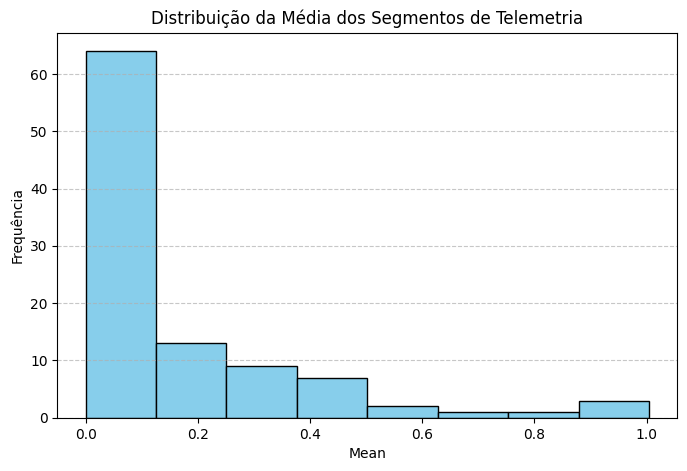


Quantitativa Continua

Estastistica 
 count    100.000000
mean       0.143726
std        0.232265
min       -0.000021
25%       -0.000002
50%        0.000005
75%        0.230570
max        1.004588
Name: mean, dtype: float64

Frequencia 
 mean
-0.000021    1
-0.000014    1
-0.000013    1
-0.000013    1
-0.000009    1
            ..
 0.652116    1
 0.868922    1
 0.926773    1
 0.941066    1
 1.004588    1
Name: count, Length: 100, dtype: int64

Média: 0.14372573678760087
Mediana: 4.552616938922765e-06
Moda: -2.073752792978724e-05
Máximo: 1.0045879999999998
Mínimo: -2.073752792978724e-05
Amplitude: 1.0046087375279296
Variância: 0.05394688968677033
Desvio Padrão: 0.23226469746125936

Q1 = -2.4883258149509806e-06
Q2 = 4.552616938922765e-06
Q3 = 0.23057029107429838


In [22]:

Estastitica_mean = amostra["mean"].describe()
freq_mean = amostra["mean"].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.hist(amostra["mean"], bins=8, color="skyblue", edgecolor="black")
plt.title("Distribuição da Média dos Segmentos de Telemetria")
plt.xlabel("Mean")
plt.ylabel("Frequência")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

media_mean = amostra["mean"].mean()
mediana_mean = amostra["mean"].median()
moda_mean = amostra["mean"].mode()[0]
maximo_mean = amostra["mean"].max()
minimo_mean = amostra["mean"].min()
amplitude_mean = maximo_mean - minimo_mean
variancia_mean = amostra["mean"].var()
desvio_padrao_mean = amostra["mean"].std()

q1_mean = amostra["mean"].quantile(0.25)
q2_mean = amostra["mean"].quantile(0.50)
q3_mean = amostra["mean"].quantile(0.75)
print()
print("Quantitativa Continua")
print()
print(f"Estastistica \n",Estastitica_mean)
print()
print(f"Frequencia \n",freq_mean)
print()
print("Média:", media_mean)
print("Mediana:", mediana_mean)
print("Moda:", moda_mean)
print("Máximo:", maximo_mean)
print("Mínimo:", minimo_mean)
print("Amplitude:", amplitude_mean)
print("Variância:", variancia_mean)
print("Desvio Padrão:", desvio_padrao_mean)
print()
print("Q1 =", q1_mean)
print("Q2 =", q2_mean)
print("Q3 =", q3_mean)

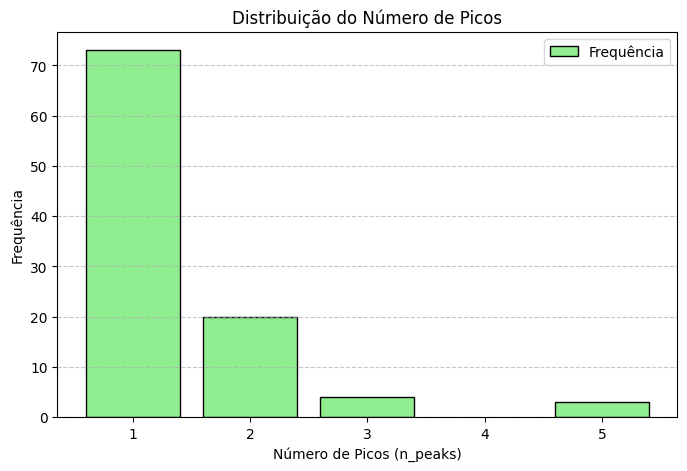


Quantitativa Discreta

Estastistica 
 count    100.000000
mean       1.400000
std        0.828775
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        5.000000
Name: n_peaks, dtype: float64

Frequencia 
 n_peaks
1    73
2    20
3     4
5     3
Name: count, dtype: int64

Média: 1.4
Mediana: 1.0
Moda: 1
Máximo: 5
Mínimo: 1
Amplitude: 4
Variância: 0.6868686868686853
Desvio Padrão: 0.8287754140107472

Q1 = 1.0
Q2 = 1.0
Q3 = 2.0


In [23]:
Estastitica_peaks = amostra["n_peaks"].describe()
freq_peaks = amostra["n_peaks"].value_counts().sort_index()

freq_peaks = amostra["n_peaks"].value_counts().sort_index()
plt.figure(figsize=(8,5))
plt.bar(freq_peaks.index, freq_peaks.values, color="lightgreen", edgecolor="black", label="Frequência")
plt.title("Distribuição do Número de Picos")
plt.xlabel("Número de Picos (n_peaks)")
plt.ylabel("Frequência")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

media_peaks = amostra["n_peaks"].mean()
mediana_peaks = amostra["n_peaks"].median()
moda_peaks = amostra["n_peaks"].mode()[0]
maximo_peaks = amostra["n_peaks"].max()
minimo_peaks = amostra["n_peaks"].min()
amplitude_peaks = maximo_peaks - minimo_peaks
variancia_peaks = amostra["n_peaks"].var()
desvio_padrao_peaks = amostra["n_peaks"].std()

q1_peaks = amostra["n_peaks"].quantile(0.25)
q2_peaks = amostra["n_peaks"].quantile(0.50)
q3_peaks= amostra["n_peaks"].quantile(0.75)
print()
print("Quantitativa Discreta")
print()
print(f"Estastistica \n",Estastitica_peaks)
print()
print(f"Frequencia \n",freq_peaks)
print()
print("Média:", media_peaks)
print("Mediana:", mediana_peaks)
print("Moda:", moda_peaks)
print("Máximo:", maximo_peaks)
print("Mínimo:", minimo_peaks)
print("Amplitude:", amplitude_peaks)
print("Variância:", variancia_peaks)
print("Desvio Padrão:", desvio_padrao_peaks)
print()
print("Q1 =", q1_peaks)
print("Q2 =", q2_peaks)
print("Q3 =", q3_peaks)

In [24]:
print("Relatório Técnico")
print()
print("Análise da variável contínua — mean (Média dos Segmentos)")
print(f"A média dos segmentos apresentou valor central de {media_mean}, com mediana de {mediana_mean}.")
print(f"A amplitude de {amplitude_mean} indica a variação total observada entre os segmentos.")
print(f"O desvio padrão de {desvio_padrao_mean} sugere o grau de dispersão dos dados em torno da média.")
print(f"O terceiro quartil (Q3) foi {q3_mean}, indicando que 75% dos registros estão abaixo desse valor.")
print()
print("Análise da variável discreta — n_peaks (Número de Picos)")

print(f"O número de picos variou entre {minimo_peaks} e {maximo_peaks}, com moda igual a {moda_peaks},indicando que esse é o número de picos mais frequente nos segmentos analisados.")
print(f"A variância de {variancia_peaks} representa a dispersão observada na quantidade de picos.")

print()
print("Conclusão")
print("Os resultados demonstram o comportamento estatístico da telemetria dos segmentos analisados.")
print("A análise da média dos sinais e da quantidade de picos permite identificar padrões operacionais e possíveis comportamentos anômalos.")
print("Esses insights podem auxiliar processos de monitoramento, detecção precoce de falhas e suporte à tomada de decisão em operações de sistemas espaciais.")

Relatório Técnico

Análise da variável contínua — mean (Média dos Segmentos)
A média dos segmentos apresentou valor central de 0.14372573678760087, com mediana de 4.552616938922765e-06.
A amplitude de 1.0046087375279296 indica a variação total observada entre os segmentos.
O desvio padrão de 0.23226469746125936 sugere o grau de dispersão dos dados em torno da média.
O terceiro quartil (Q3) foi 0.23057029107429838, indicando que 75% dos registros estão abaixo desse valor.

Análise da variável discreta — n_peaks (Número de Picos)
O número de picos variou entre 1 e 5, com moda igual a 1,indicando que esse é o número de picos mais frequente nos segmentos analisados.
A variância de 0.6868686868686853 representa a dispersão observada na quantidade de picos.

Conclusão
Os resultados demonstram o comportamento estatístico da telemetria dos segmentos analisados.
A análise da média dos sinais e da quantidade de picos permite identificar padrões operacionais e possíveis comportamentos anômalos.
E